In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as smp

# Problem 1

Recall that we previously showed that, for the SIR model with a constant reqruitment rate $\Lambda$ and per-capita mortality rate $\mu$

$$\begin{gather}\dot S =& \Lambda - \beta SI - \mu S\\
\dot I =& \beta SI - (\gamma + \mu)I \\
\dot R =& \gamma I - \mu R\end{gather}$$

the total population size $N = S + I + R$ follows $\dot N = \lambda - \mu N$ and thus $S+I+R=\lambda/\mu$ defines an attracting (locally $\mathbb{R}^2$) invariant manifold embeded in $\mathbb{R}^3$. Let us restrict our focus here to the dynamics within the invariant manifold, given by $R=\Lambda/\mu -S-I$ (so $S_0 + I_o \leq\Lambda\mu$) and

$$\begin{align*}\dot S =&\; \Lambda - \beta SI - \mu S\\
\dot I =&\; \beta SI - (\gamma + \mu)I \end{align*}$$

## a)

The basic reproduction number for this model can be shown to be $\mathcal{R}_0=\frac{\beta\Lambda/\mu}{\gamma + \mu}$. Use $\tau = (\gamma + \mu)t$, with $(x,y)=\left(\frac{\beta}{\gamma + \mu}S,\frac{\beta}{\gamma+\mu}I\right)$, and $r=\frac{\mu}{\mu + \gamma}$ to show that the above system can be written as 

$$\begin{align*}\dot x =&\; r(\mathcal{R}_0 -x) -xy \\
\dot y =&\; (x-1)y \end{align*}$$

---

$$\begin{align}\dot x =&\; r(\mathcal{R}_0 -x) -xy \\
\dot y =&\; (x-1)y\end{align}$$

Subbing in values for $(x,y)$

$$\begin{gather}\frac{d}{dt}  \left[\frac{\beta}{\gamma + \mu}S\right]  =&\; r(\mathcal{R}_0 -\left[\frac{\beta}{\gamma + \mu}S\right]) -\left[\frac{\beta}{\gamma + \mu}S\right]\left[\frac{\beta}{\gamma + \mu}I\right] \\
\frac{d}{dt} \left[\frac{\beta}{\gamma + \mu}I\right] =&\; (\left[\frac{\beta}{\gamma + \mu}S\right]-1)\left[\frac{\beta}{\gamma + \mu}I\right]\end{gather}$$

Doing algebra

$$\begin{align*}\dot S  =&\; r\left(\frac{\gamma + \mu}{\beta}\mathcal{R}_0 -S\right) -\frac{\beta}{\gamma + \mu}SI\\
\dot I =&\; \left(\frac{\beta}{\gamma + \mu}S-1\right)I\end{align*}$$

Plugging in $\mathcal{R}_0=\frac{\beta\Lambda/\mu}{\gamma + \mu}$

$$\begin{align*}\dot S  =&\; r\left(\frac{\Lambda}{\mu} -S\right) -\frac{\beta}{\gamma + \mu}SI\\
\dot I =&\; \left(\frac{\beta}{\gamma + \mu}S-1\right)I\end{align*}$$

Plugging in $r=\frac{\mu}{\mu + \gamma}$

$$\begin{align*}\dot S  =&\; \frac{\Lambda}{\mu + \gamma}  - \frac{\mu}{\mu + \gamma}S - \frac{\beta}{\gamma + \mu}SI\\
\dot I =&\; \frac{\beta}{\gamma + \mu}SI-I\end{align*}$$

Considering the time derivative with respect to $\tau = (\gamma + \mu)t$

$$\boxed{\begin{align*}\dot S  =&\; \Lambda  - \mu S - \beta SI\\
\dot I =&\; \beta SI-I(\gamma + \mu)\end{align*}}$$


## b)

The disease free equilibrium (DFE) for this system is $(\mathcal{R}_0,0)$. Evaluate the corresponding Jacobian and show that the DFE becomes non-hyperbolic when $\mathcal{R}_0=1$ (that is, treating $\mathcal{R}_0$ as a parameter, a bifurcation likely occurs at $\mathcal{R_0}=1$).

---

In [3]:
r, R, x, y = smp.symbols(r'r \mathcal{R}_0 x y')

dx = r*(R-x)-x*y
dy = (x-1)*y
dR = 0

In [12]:
eq1 = smp.solve([dx,dy],[x,y])[0]
eq1

(\mathcal{R}_0, 0)

In [13]:
eq2 = smp.solve([dx,dy],[x,y])[1]
eq2

(-(-\mathcal{R}_0*r + r*(\mathcal{R}_0 - 1))/r, r*(\mathcal{R}_0 - 1))

In [17]:
# Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y),smp.diff(dx,R)],
#                   [smp.diff(dy,x),smp.diff(dy,y),smp.diff(dy,R)],
#                   [smp.diff(dR,x),smp.diff(dR,y),smp.diff(dR,R)]])
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y)],
                  [smp.diff(dy,x),smp.diff(dy,y)]])
Jac

Matrix([
[-r - y,    -x],
[     y, x - 1]])

In [18]:
# J0 = Jac.subs([[x,R],[y,0],[R,0]])
J0 = Jac.subs([[x,R],[y,0]])
J0

Matrix([
[-r,    -\mathcal{R}_0],
[ 0, \mathcal{R}_0 - 1]])

In [22]:
eigs0 = J0.subs(R,0).eigenvects()
eigs0

[(-1,
  1,
  [Matrix([
   [0],
   [1]])]),
 (-r,
  1,
  [Matrix([
   [1],
   [0]])])]

In [23]:
eigs1 = J0.subs(R,1).eigenvects()
eigs1

[(0,
  1,
  [Matrix([
   [-1/r],
   [   1]])]),
 (-r,
  1,
  [Matrix([
   [1],
   [0]])])]

In [24]:
eigs2 = J0.subs(R,2).eigenvects()
eigs2

[(1,
  1,
  [Matrix([
   [-2/(r + 1)],
   [         1]])]),
 (-r,
  1,
  [Matrix([
   [1],
   [0]])])]

## c)


Do a center manifold reduction of equations 1 about the DFE and $\mathcal{R}_0=1$

---

In [32]:
c, s = smp.symbols('c s')

cs = smp.Matrix([[c],[s]])
X  = smp.Matrix([[x],[y]])
dX = smp.Matrix([[dx],[dy]])

In [33]:
vc = eigs1[0][2][0]
vs = eigs1[1][2][0]

V  = smp.Matrix([vc.T,vs.T]).T
VT = V.T

In [34]:
X_cs = V@cs
X_cs

Matrix([
[-c/r + s],
[       c]])

In [38]:
dcs = VT@dX
dcs

Matrix([
[y*(x - 1) - (r*(\mathcal{R}_0 - x) - x*y)/r],
[                r*(\mathcal{R}_0 - x) - x*y]])

In [49]:
dcs = dcs.subs([[x,X_cs[0]],[y,X_cs[1]]])
dc = dcs[0].expand()
ds = dcs[1].expand()

In [50]:
dc

-\mathcal{R}_0 - c**2/r - c**2/r**2 + c*s - c + c*s/r - c/r + s

In [51]:
ds

\mathcal{R}_0*r + c**2/r - c*s + c - r*s

In [54]:
A = dc.coeff(c,1).coeff(s,0)
A 

-1 - 1/r

In [55]:
g1 = dc - A*c
g1.expand()

-\mathcal{R}_0 - c**2/r - c**2/r**2 + c*s + c*s/r + s

In [56]:
B = ds.coeff(c,0).coeff(s,1)
B 

-r

In [57]:
g2 = ds - B*s
g2.expand()

\mathcal{R}_0*r + c**2/r - c*s + c

In [58]:
a1, a2, a3 = smp.symbols('a_1 a_2 a_3')

h  = a1*c**2 + a2*c*R + a3*R**2
dh = smp.diff(h,c)
dh

\mathcal{R}_0*a_2 + 2*a_1*c

In [59]:
N = dh*(A*c + g1) - B*h - g1
N = N.subs(s,h).expand()
N

\mathcal{R}_0**3*a_2*a_3*c + \mathcal{R}_0**3*a_2*a_3*c/r + \mathcal{R}_0**3*a_2*a_3 + 2*\mathcal{R}_0**2*a_1*a_3*c**2 + 2*\mathcal{R}_0**2*a_1*a_3*c**2/r + 2*\mathcal{R}_0**2*a_1*a_3*c + \mathcal{R}_0**2*a_2**2*c**2 + \mathcal{R}_0**2*a_2**2*c**2/r + \mathcal{R}_0**2*a_2**2*c - \mathcal{R}_0**2*a_2 - \mathcal{R}_0**2*a_3*c - \mathcal{R}_0**2*a_3*c/r + \mathcal{R}_0**2*a_3*r - \mathcal{R}_0**2*a_3 + 3*\mathcal{R}_0*a_1*a_2*c**3 + 3*\mathcal{R}_0*a_1*a_2*c**3/r + 3*\mathcal{R}_0*a_1*a_2*c**2 - 2*\mathcal{R}_0*a_1*c - \mathcal{R}_0*a_2*c**2 - 2*\mathcal{R}_0*a_2*c**2/r - \mathcal{R}_0*a_2*c**2/r**2 + \mathcal{R}_0*a_2*c*r - 2*\mathcal{R}_0*a_2*c - \mathcal{R}_0*a_2*c/r + \mathcal{R}_0 + 2*a_1**2*c**4 + 2*a_1**2*c**4/r + 2*a_1**2*c**3 - a_1*c**3 - 3*a_1*c**3/r - 2*a_1*c**3/r**2 + a_1*c**2*r - 3*a_1*c**2 - 2*a_1*c**2/r + c**2/r + c**2/r**2

In [64]:
coeff_c2 = N.coeff(c,2).coeff(R,0)
coeff_c2

a_1*r - 3*a_1 - 2*a_1/r + 1/r + r**(-2)

In [66]:
coeff_R2 = N.coeff(c,0).coeff(R,2)
coeff_R2

-a_2 + a_3*r - a_3

In [67]:
coeff_cR = N.coeff(c,1).coeff(R,1)
coeff_cR

-2*a_1 + a_2*r - 2*a_2 - a_2/r

In [71]:
coeff = smp.solve([coeff_c2,coeff_R2,coeff_cR],[a1,a2,a3])
coeff

{a_1: (-r - 1)/(r**3 - 3*r**2 - 2*r),
 a_2: (-2*r - 2)/(r**4 - 5*r**3 + 3*r**2 + 7*r + 2),
 a_3: (-2*r - 2)/(r**5 - 6*r**4 + 8*r**3 + 4*r**2 - 5*r - 2)}

In [80]:
h_fill = h.subs([[a1,coeff[a1]],
                 [a2,coeff[a2]],
                 [a3,coeff[a3]]]).expand()
h_fill

-2*\mathcal{R}_0**2*r/(r**5 - 6*r**4 + 8*r**3 + 4*r**2 - 5*r - 2) - 2*\mathcal{R}_0**2/(r**5 - 6*r**4 + 8*r**3 + 4*r**2 - 5*r - 2) - 2*\mathcal{R}_0*c*r/(r**4 - 5*r**3 + 3*r**2 + 7*r + 2) - 2*\mathcal{R}_0*c/(r**4 - 5*r**3 + 3*r**2 + 7*r + 2) - c**2*r/(r**3 - 3*r**2 - 2*r) - c**2/(r**3 - 3*r**2 - 2*r)

In [96]:
dc_fill = dc.subs(s,h_fill).expand()
dc_fill

-2*\mathcal{R}_0**2*c*r/(r**5 - 6*r**4 + 8*r**3 + 4*r**2 - 5*r - 2) - 2*\mathcal{R}_0**2*c/(r**6 - 6*r**5 + 8*r**4 + 4*r**3 - 5*r**2 - 2*r) - 4*\mathcal{R}_0**2*c/(r**5 - 6*r**4 + 8*r**3 + 4*r**2 - 5*r - 2) - 2*\mathcal{R}_0**2*r/(r**5 - 6*r**4 + 8*r**3 + 4*r**2 - 5*r - 2) - 2*\mathcal{R}_0**2/(r**5 - 6*r**4 + 8*r**3 + 4*r**2 - 5*r - 2) - 2*\mathcal{R}_0*c**2*r/(r**4 - 5*r**3 + 3*r**2 + 7*r + 2) - 2*\mathcal{R}_0*c**2/(r**5 - 5*r**4 + 3*r**3 + 7*r**2 + 2*r) - 4*\mathcal{R}_0*c**2/(r**4 - 5*r**3 + 3*r**2 + 7*r + 2) - 2*\mathcal{R}_0*c*r/(r**4 - 5*r**3 + 3*r**2 + 7*r + 2) - 2*\mathcal{R}_0*c/(r**4 - 5*r**3 + 3*r**2 + 7*r + 2) - \mathcal{R}_0 - c**3*r/(r**3 - 3*r**2 - 2*r) - c**3/(r**4 - 3*r**3 - 2*r**2) - 2*c**3/(r**3 - 3*r**2 - 2*r) - c**2*r/(r**3 - 3*r**2 - 2*r) - c**2/(r**3 - 3*r**2 - 2*r) - c**2/r - c**2/r**2 - c - c/r

## d)

Analyze the resulting 1-dimensional dynamics on the center manifold to show that a transcritical bifurcation is occurring at $\mathcal{R}_0=1$. Note: this can be a simple graphical analysis of that center manifold equation, or a comparison with bifurcation normal forms. You do not need to do a full normal form calculation for this step!! If you are unable to complete part (c) above, please consult with your instructor about how to proceed with part (d).

---

In [97]:
dc_fill.subs(r,2)

-9*\mathcal{R}_0**2*c/4 - 3*\mathcal{R}_0**2/2 - 9*\mathcal{R}_0*c**2/4 - 3*\mathcal{R}_0*c/2 - \mathcal{R}_0 + 9*c**3/16 - 3*c**2/8 - 3*c/2

In [99]:
dc_func = smp.lambdify([R,c],dc_fill.subs(r,2))
def dR_func(x,y):
    return 0

Text(0.5, 0, '$\\mathcal{R}_0$')

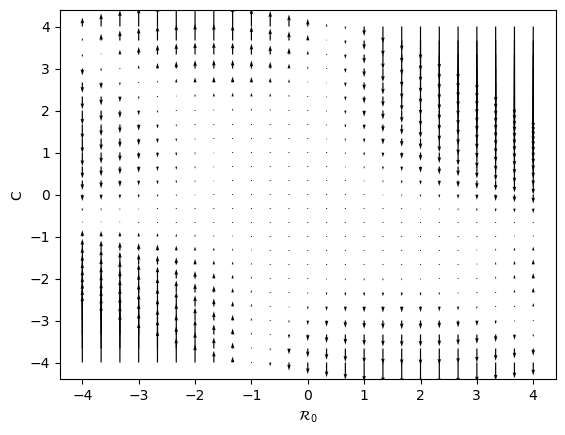

In [121]:
Rv = np.linspace(-4,4,25)
cv = np.linspace(-4,4,25)

RG, cG = np.meshgrid(Rv,cv)
plt.quiver(RG,cG,dR_func(RG,cG),dc_func(RG,cG))
plt.ylabel('C')
plt.xlabel(r'$\mathcal{R}_0$')

Text(0.5, 0, '$\\mathcal{R}_0$')

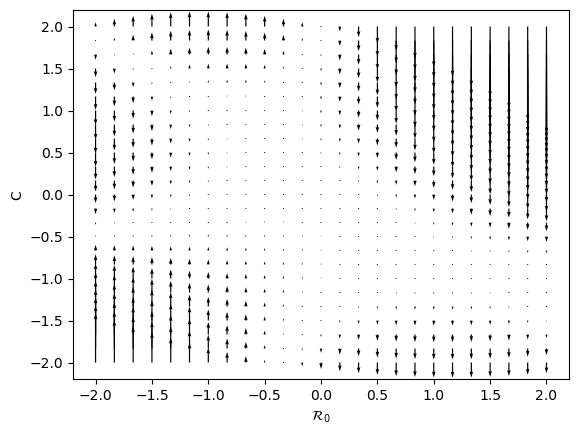

In [122]:
Rv = np.linspace(-2,2,25)
cv = np.linspace(-2,2,25)

RG, cG = np.meshgrid(Rv,cv)
plt.quiver(RG,cG,dR_func(RG,cG),dc_func(RG,cG))
plt.ylabel('C')
plt.xlabel(r'$\mathcal{R}_0$')

Text(0.5, 0, '$\\mathcal{R}_0$')

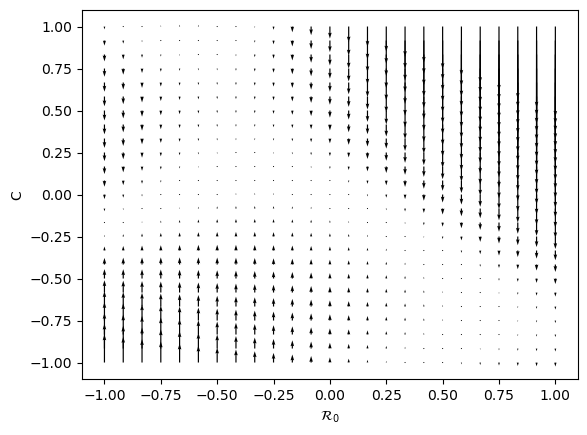

In [123]:
Rv = np.linspace(-1,1,25)
cv = np.linspace(-1,1,25)

RG, cG = np.meshgrid(Rv,cv)
plt.quiver(RG,cG,dR_func(RG,cG),dc_func(RG,cG))
plt.ylabel('C')
plt.xlabel(r'$\mathcal{R}_0$')

Text(0.5, 0, '$\\mathcal{R}_0$')

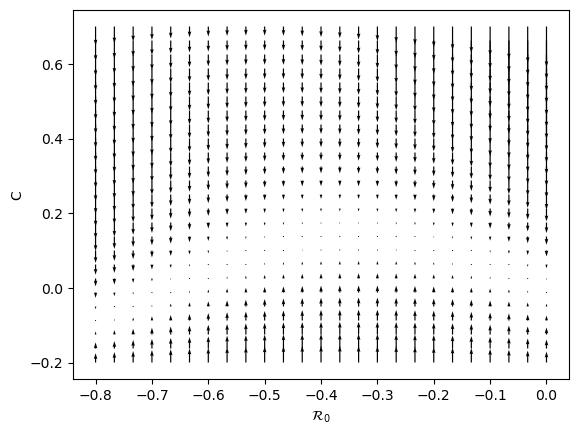

In [124]:
Rv = np.linspace(-0.8,0,25)
cv = np.linspace(-0.2,0.7,25)

RG, cG = np.meshgrid(Rv,cv)
plt.quiver(RG,cG,dR_func(RG,cG),dc_func(RG,cG))
plt.ylabel('C')
plt.xlabel(r'$\mathcal{R}_0$')

Text(0.5, 0, '$\\mathcal{R}_0$')

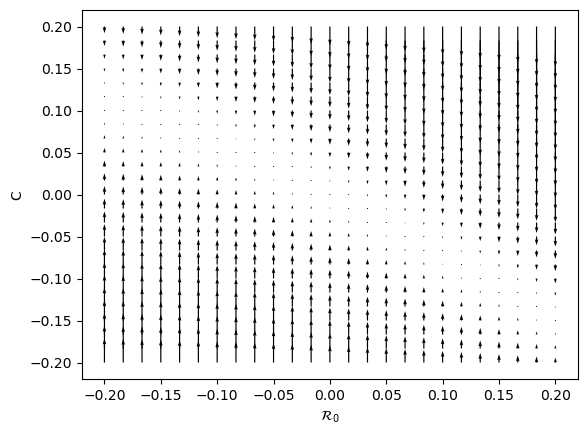

In [125]:
Rv = np.linspace(-0.2,0.2,25)
cv = np.linspace(-0.2,0.2,25)

RG, cG = np.meshgrid(Rv,cv)
plt.quiver(RG,cG,dR_func(RG,cG),dc_func(RG,cG))
plt.ylabel('C')
plt.xlabel(r'$\mathcal{R}_0$')

# Problem 2

Recall the period doubling cascade to chaos in the logistic map

$$x_{n+1}=rx_n(1-x_n)$$

In ecological modeling, researchers sometimes use a more flexible version of the continuous time logistic equation $\dot N = rN(1-N/K)$ ̇(or if we set $x=N/K$, $\dot x = rx(1-x)$) known as the theta-logistic model: $\dot x = rx(1-x^\theta)$. Here $\theta > 0$ gives us a longer initial exponential growth phase, while $\theta \in (0,1)$ causes a stronger nonlinear effect and dampens exponential growth sooner than in the logistic case ($\theta = 1$).

Your goal is to look at the dynamics of the analogous map, which we’ll call the theta-logistic map:

$$x_{n+1} = rx_n(1-x_n^\theta)$$

## a)

Show that in the continuous time theta-logistic model, the local asymptotic stability of $x=0$ and of $x=1$ are not affected by the choice of $\theta$ since we require $\theta>0$.

---

## b)

Code the bifurcation diagram for the logistic map. Generate the analogous bifurcation diagram for some $\theta\in(0,1)$ and some $\theta>1$. **Show all three bifurcation diagrams in your solution, and discuss wow changing $\theta$ above or below $1$ seems to change the bifurcation structure**.

---

In [175]:
from numpy.random import random

/tmp/ipykernel_1784573/2074929992.py:18: RuntimeWarning: invalid value encountered in scalar power
  x1 = r*x1*(1-x1**theta1)
/tmp/ipykernel_1784573/2074929992.py:20: RuntimeWarning: invalid value encountered in scalar power
  x3 = r*x3*(1-x3**theta3)
/tmp/ipykernel_1784573/2074929992.py:19: RuntimeWarning: overflow encountered in scalar multiply
  x2 = r*x2*(1-x2**theta2)


Text(0.5, 1.0, '$\\theta=$0.4')

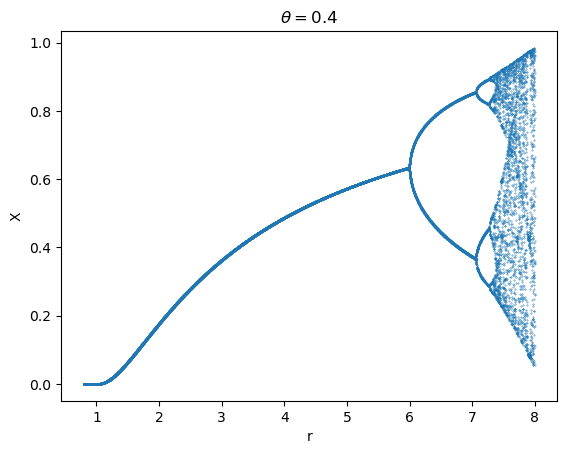

In [316]:
theta1 = 0.4
theta2 = 1
theta3 = 1.9

r_set = np.arange(0.8,8,0.0001)
steps = 500
X0 = 2


X1 = []
X2 = []
X3 = []
for r in r_set:
    x1 = X0*random()
    x2 = x1
    x3 = x1
    for n in range(steps):
        x1 = r*x1*(1-x1**theta1)
        x2 = r*x2*(1-x2**theta2)
        x3 = r*x3*(1-x3**theta3)
        
    X1.append(x1)
    X2.append(x2)
    X3.append(x3)
    
plt.scatter(r_set,X1,s=0.1)


plt.ylabel('X')
plt.xlabel('r')
plt.title(fr'$\theta=${theta}')

Text(0.5, 0, 'r')

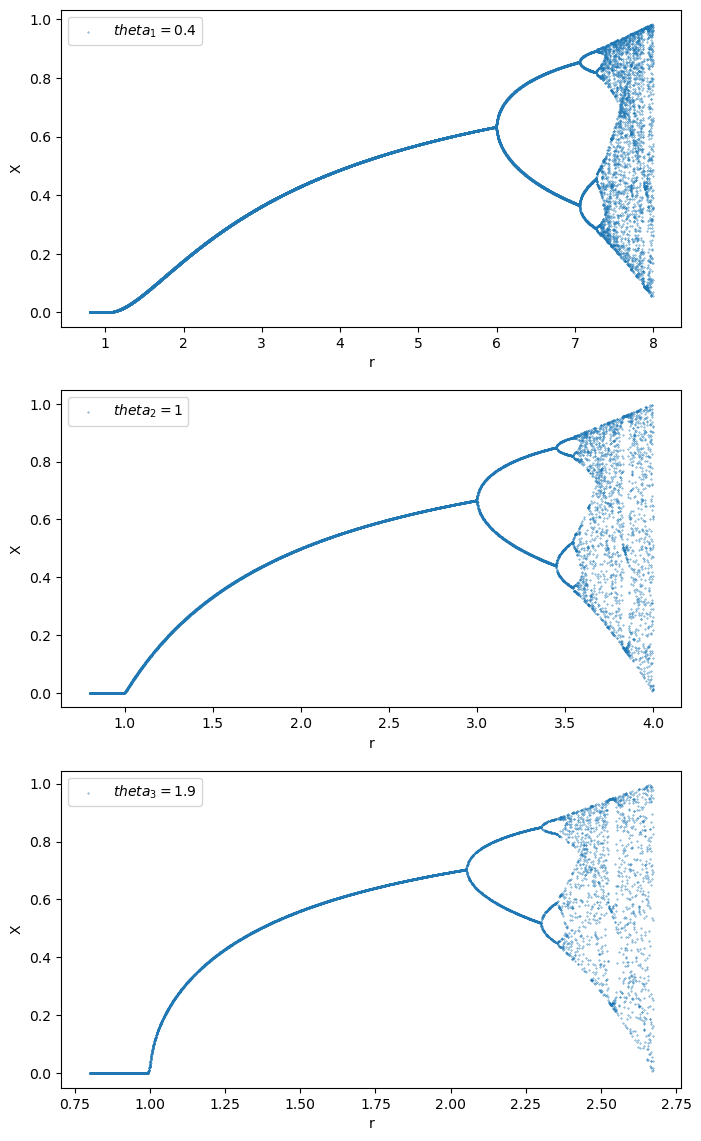

In [324]:
fig, (p1,p2,p3) = plt.subplots(3,1,figsize=(8,14))


p1.scatter(r_set,X1,
           s=0.1,label=fr'$theta_1=${theta1}')
p1.legend()
p1.set_ylabel('X')
p1.set_xlabel('r')
# p1.set_title(fr'$\theta=${theta1}')


p2.scatter(r_set,X2,s=0.1,label=fr'$theta_2=${theta2}')
p2.legend()
p2.set_ylabel('X')
p2.set_xlabel('r')
# p2.set_title(fr'$\theta=${theta2}')


p3.scatter(r_set,X3,s=0.1,label=fr'$theta_3=${theta3}')
p3.legend()
p3.set_ylabel('X')
p3.set_xlabel('r')
# p3.set_title(fr'$\theta=${theta3}')

## c)

To add some analytical results to these computational findings, one could analyze the various period doubling bifurcations and their dependence on $\theta$. Find the fixed point (analogous to the single fixed point that exists for $r>1$ in the logistic map), and determine it’s stability conditions for $r>1$ and $\theta>0$. Recall that, for a 1D map, the Jacobian is just the $1\times 1$ diagonal matrix (that is, the scalar) $f'(x_{eq})$. Also recall the corresponding eigenvalue condition at a flip bifurcation. **Find where the fixed point of the theta-logistic map loses stability via a flip bifurcation, and discuss how this threshold is shifted by increasing or decreasing $\theta$ relative to $\theta = 1$. Discuss this in the context of your numerical results for part (b) above.**

---